# Categorized Dataset Exploration
## Tunisian Dialogue System Data Analysis

This notebook explores and analyzes the categorized.csv dataset containing Tunisian dialogue data with categories, instructions, and responses.

## Section 1: Load and Inspect the Dataset

In [9]:
# Section 1: Load and Inspect the Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset
df = pd.read_csv(R'C:\\Users\\user\\OneDrive\\Bureau\\TunisianDialogSystem\\llm\\sft\\data\\raw\\categorized.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names and Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (12576, 3)

Column Names and Types:
category       object
instruction    object
response       object
dtype: object

First 5 rows:


,category,instruction,response
0,cultural_knowledge,أعطيني لمحة على أشهر أنواع السلايط في الكوجينة...,الكوجينة التونسية معروفة بتنوع السلايط متاعها،...
1,storytelling,كيفاش يعتبر تكريم كريم بقير وزهرة سليم في مجال...,تكريم كريم بقير وزهرة سليم (مؤسسي InstaDeep) ي...
2,cultural_knowledge,كيفاش تنجم تونس تحافظ على التراث الفلكي الإسلا...,تونس تنجم تواصل في الثنية هذه عن طريق:\n• عمل ...
3,storytelling,شكونو منجي باوندي، العالم التونسي اللي خذا جائ...,منجي باوندي هو عالم كيمياء أمريكي من أصل تونسي...
4,storytelling,كيفاش كرمت تونس الفلكي اللي اكتشف كويكب وسماه ...,الفلكي الدنماركي ريشارد مارتن ويست اكتشف كويكب...


## Section 2: Explore Data Structure and Content

In [10]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nMissing Values Percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

# Check for duplicates
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Display data info
print("\nDataset Info:")
print(df.info())

# Show sample entries
print("\n--- Sample Entries ---")
for idx, row in df.head(3).iterrows():
    print(f"\nEntry {idx + 1}:")
    for col in df.columns:
        value = str(row[col])[:100] + "..." if len(str(row[col])) > 100 else row[col]
        print(f"  {col}: {value}")

Missing Values:
category       0
instruction    0
response       0
dtype: int64

Missing Values Percentage:
category       0.0
instruction    0.0
response       0.0
dtype: float64

Duplicate Rows: 704

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12576 entries, 0 to 12575
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   category     12576 non-null  object
 1   instruction  12576 non-null  object
 2   response     12576 non-null  object
dtypes: object(3)
memory usage: 294.9+ KB
None

--- Sample Entries ---

Entry 1:
  category: cultural_knowledge
  instruction: أعطيني لمحة على أشهر أنواع السلايط في الكوجينة التونسية؟
  response: الكوجينة التونسية معروفة بتنوع السلايط متاعها، وهذه أهمها:
• سلاطة مشوية: فلفل وطماطم وبصل وثوم يتشو...

Entry 2:
  category: storytelling
  instruction: كيفاش يعتبر تكريم كريم بقير وزهرة سليم في مجال الذكاء الاصطناعي رسالة أمل للشباب التونسي؟
  response: تكريم كريم بقير وزه

## Section 3: Analyze Categories Distribution

Category Distribution:
category
cultural_knowledge          3509
advice_guidance             3213
general_knowledge           1316
task_oriented               1039
emotional_support            855
everyday_conversation        795
storytelling                 703
student_life                 613
opinions_recommendations     533
Name: count, dtype: int64

Total Categories: 9

Top Categories:
category
cultural_knowledge          3509
advice_guidance             3213
general_knowledge           1316
task_oriented               1039
emotional_support            855
everyday_conversation        795
storytelling                 703
student_life                 613
opinions_recommendations     533
Name: count, dtype: int64


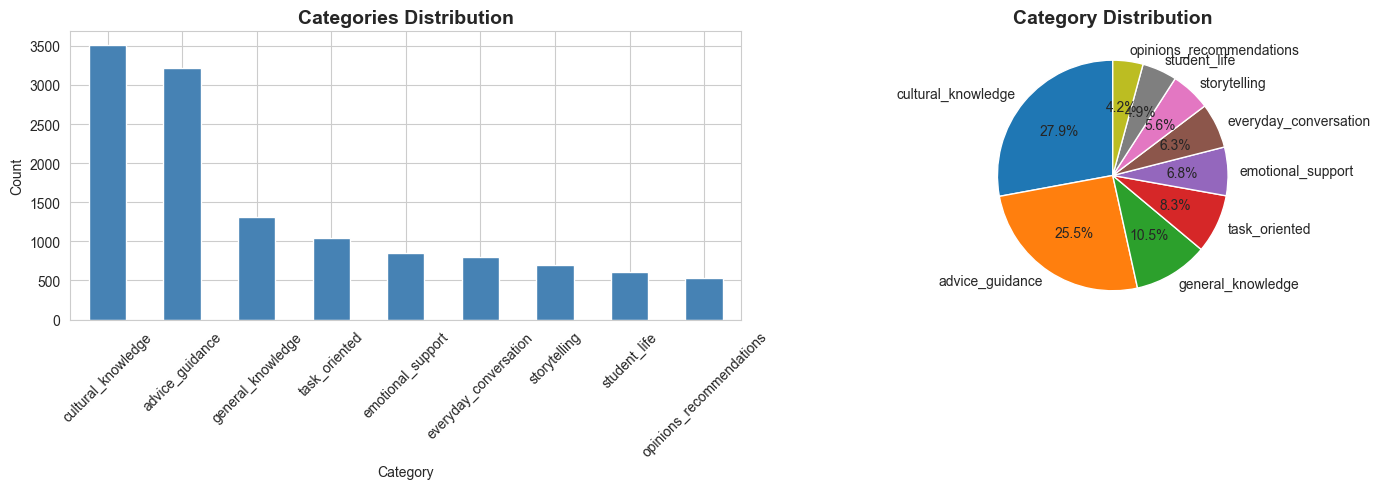

In [14]:
# Category distribution
category_counts = df['category'].value_counts()
print("Category Distribution:")
print(category_counts)
print(f"\nTotal Categories: {len(category_counts)}")
print(f"\nTop Categories:")
print(category_counts.head(10))

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
category_counts.head(15).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Categories Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart for top categories
top_10_cats = category_counts.head(10)
other_count = category_counts[10:].sum()
if other_count > 0:
    plot_data = pd.concat([top_10_cats, pd.Series({'Other': other_count})])
else:
    plot_data = top_10_cats

plot_data.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Category Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Section 4: Examine Instruction and Response Patterns

Instruction Statistics:
  Average length: 55.98 characters
  Average words: 9.94
  Min length: 9
  Max length: 479

Response Statistics:
  Average length: 186.83 characters
  Average words: 32.25
  Min length: 1
  Max length: 1067


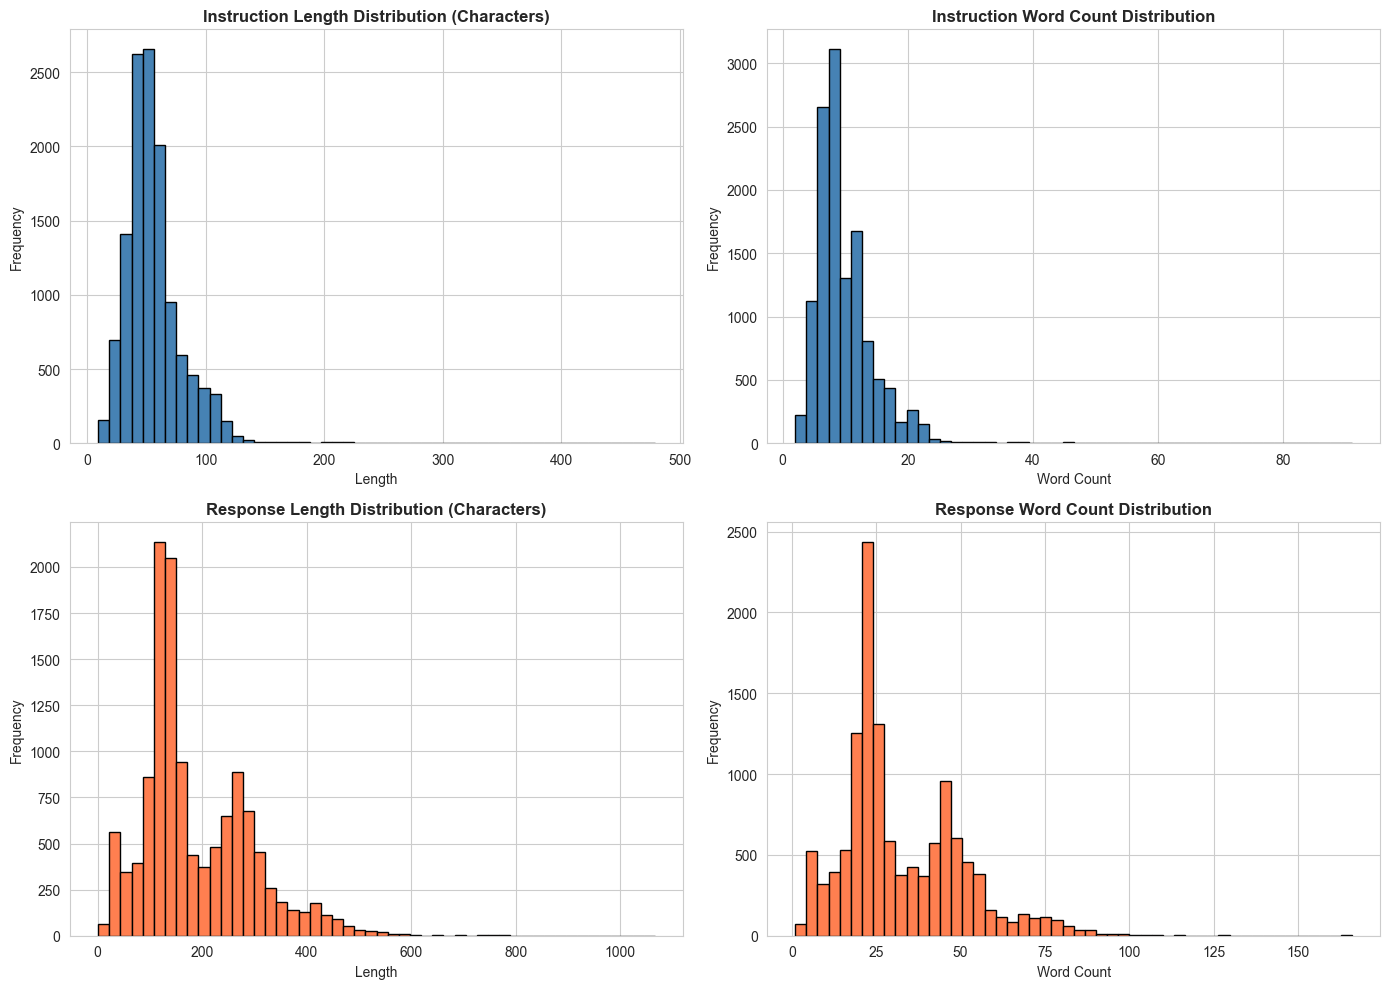

In [15]:
# Analyze text lengths
df['instruction_length'] = df['instruction'].fillna('').apply(len)
df['instruction_words'] = df['instruction'].fillna('').apply(lambda x: len(x.split()))
df['response_length'] = df['response'].fillna('').apply(len)
df['response_words'] = df['response'].fillna('').apply(lambda x: len(x.split()))

# Summary statistics for text
print("Instruction Statistics:")
print(f"  Average length: {df['instruction_length'].mean():.2f} characters")
print(f"  Average words: {df['instruction_words'].mean():.2f}")
print(f"  Min length: {df['instruction_length'].min()}")
print(f"  Max length: {df['instruction_length'].max()}")

print("\nResponse Statistics:")
print(f"  Average length: {df['response_length'].mean():.2f} characters")
print(f"  Average words: {df['response_words'].mean():.2f}")
print(f"  Min length: {df['response_length'].min()}")
print(f"  Max length: {df['response_length'].max()}")

# Visualize text length distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Instruction length distribution
axes[0, 0].hist(df['instruction_length'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Instruction Length Distribution (Characters)', fontweight='bold')
axes[0, 0].set_xlabel('Length')
axes[0, 0].set_ylabel('Frequency')

# Instruction words distribution
axes[0, 1].hist(df['instruction_words'], bins=50, color='steelblue', edgecolor='black')
axes[0, 1].set_title('Instruction Word Count Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')

# Response length distribution
axes[1, 0].hist(df['response_length'], bins=50, color='coral', edgecolor='black')
axes[1, 0].set_title('Response Length Distribution (Characters)', fontweight='bold')
axes[1, 0].set_xlabel('Length')
axes[1, 0].set_ylabel('Frequency')

# Response words distribution
axes[1, 1].hist(df['response_words'], bins=50, color='coral', edgecolor='black')
axes[1, 1].set_title('Response Word Count Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Section 5: Generate Summary Statistics

In [16]:
# Create comprehensive summary by category
summary_stats = []
for cat in df['category'].unique():
    cat_data = df[df['category'] == cat]
    summary_stats.append({
        'Category': cat,
        'Count': len(cat_data),
        'Avg_Instruction_Length': cat_data['instruction_length'].mean(),
        'Avg_Response_Length': cat_data['response_length'].mean(),
        'Avg_Instruction_Words': cat_data['instruction_words'].mean(),
        'Avg_Response_Words': cat_data['response_words'].mean(),
        'Missing_Response': cat_data['response'].isnull().sum()
    })

summary_df = pd.DataFrame(summary_stats).sort_values('Count', ascending=False)
print("Summary Statistics by Category:")
print(summary_df.to_string())

# Overall statistics
print("\n" + "="*60)
print("OVERALL DATASET STATISTICS")
print("="*60)
print(f"Total Entries: {len(df)}")
print(f"Total Categories: {df['category'].nunique()}")
print(f"Entries with Missing Response: {df['response'].isnull().sum()}")
print(f"Entries with Missing Instruction: {df['instruction'].isnull().sum()}")
print(f"Duplicate Entries: {df.duplicated().sum()}")
print(f"\nAverage Instruction Length: {df['instruction_length'].mean():.2f} characters")
print(f"Average Response Length: {df['response_length'].mean():.2f} characters")
print(f"Average Instruction Words: {df['instruction_words'].mean():.2f}")
print(f"Average Response Words: {df['response_words'].mean():.2f}")

Summary Statistics by Category:
                   Category  Count  Avg_Instruction_Length  Avg_Response_Length  Avg_Instruction_Words  Avg_Response_Words  Missing_Response
0        cultural_knowledge   3509               55.483044           178.110288               9.898547           30.384440                 0
2           advice_guidance   3213               64.926860           171.293495              11.766885           29.762216                 0
3         general_knowledge   1316               58.234802           194.346505              10.243161           33.749240                 0
4             task_oriented   1039               50.485082           223.077960               8.695861           38.610202                 0
7         emotional_support    855               56.964912           139.780117              10.897076           25.452632                 0
6     everyday_conversation    795               30.094340            96.752201               5.241509           16.856604

## Section 6: Visualize Key Insights

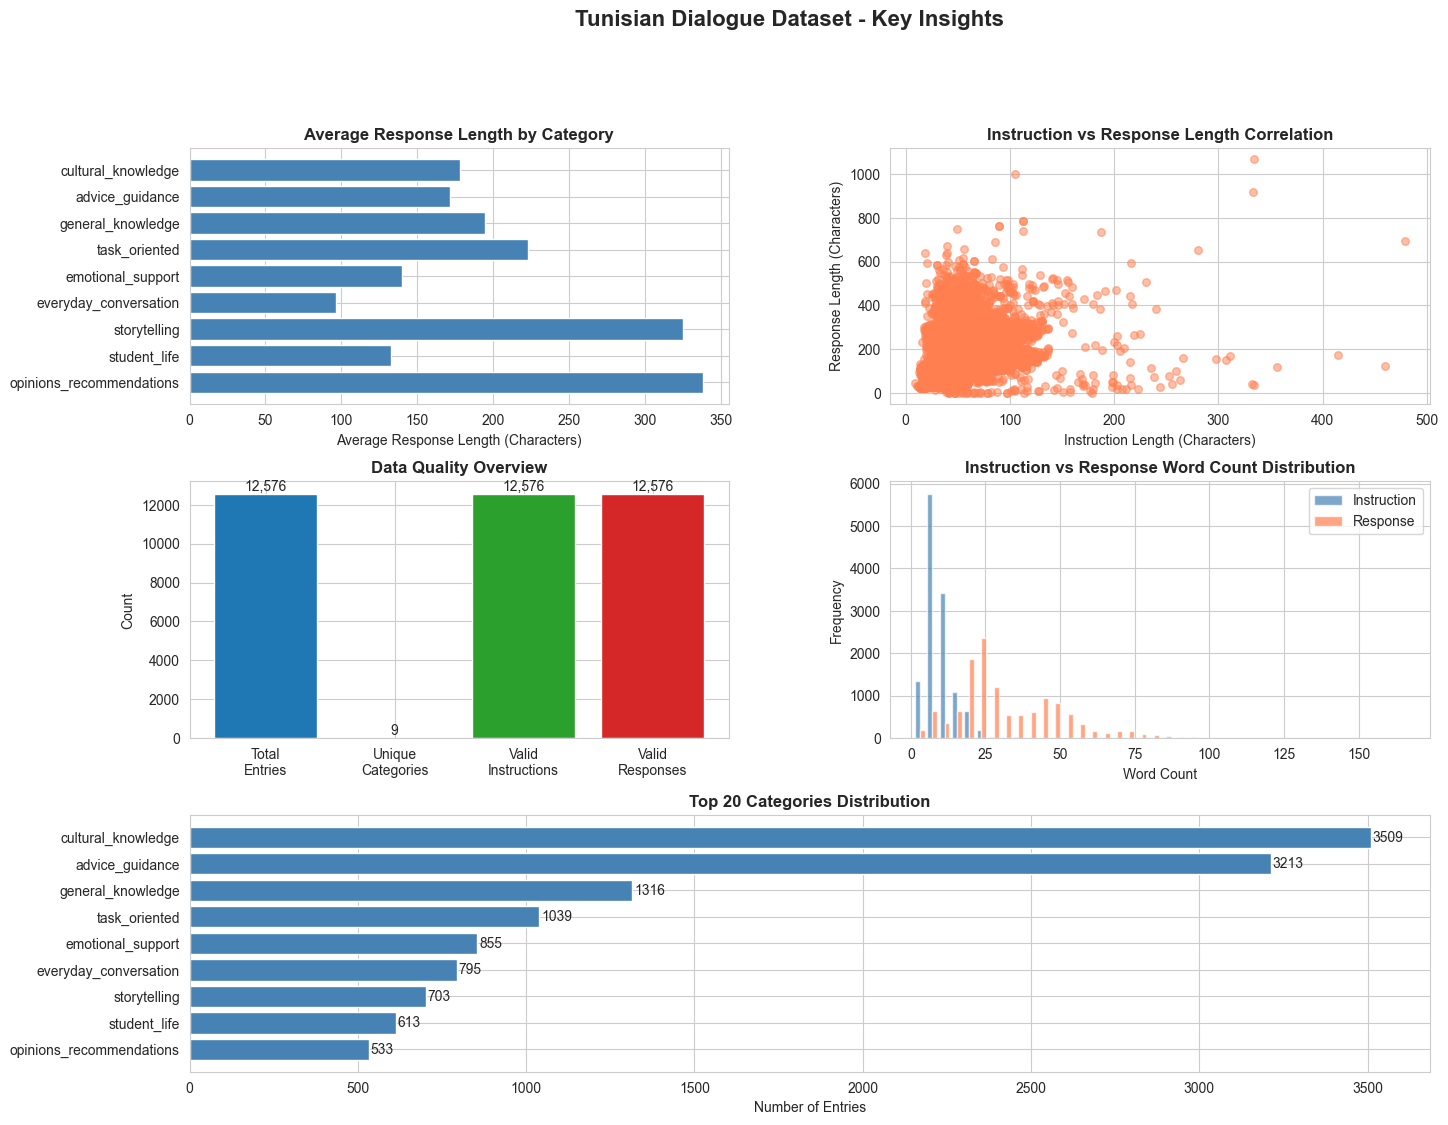


Visualization complete!


In [18]:
# Create advanced visualizations
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Response length by category (top 10)
ax1 = fig.add_subplot(gs[0, 0])
top_cats = df['category'].value_counts().head(10).index
cat_response_lengths = [df[df['category'] == cat]['response_length'].mean() for cat in top_cats]
ax1.barh(range(len(top_cats)), cat_response_lengths, color='steelblue')
ax1.set_yticks(range(len(top_cats)))
ax1.set_yticklabels(top_cats)
ax1.set_xlabel('Average Response Length (Characters)')
ax1.set_title('Average Response Length by Category', fontweight='bold')
ax1.invert_yaxis()

# 2. Instruction vs Response length scatter
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(df['instruction_length'], df['response_length'], alpha=0.5, s=30, color='coral')
ax2.set_xlabel('Instruction Length (Characters)')
ax2.set_ylabel('Response Length (Characters)')
ax2.set_title('Instruction vs Response Length Correlation', fontweight='bold')

# 3. Data quality metrics
ax3 = fig.add_subplot(gs[1, 0])
quality_metrics = [
    len(df),
    df['category'].nunique(),
    (df['instruction'].notna().sum()),
    (df['response'].notna().sum()),
]
labels = ['Total\nEntries', 'Unique\nCategories', 'Valid\nInstructions', 'Valid\nResponses']
bars = ax3.bar(labels, quality_metrics, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax3.set_ylabel('Count')
ax3.set_title('Data Quality Overview', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom')

# 4. Word count distribution comparison
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist([df['instruction_words'], df['response_words']], bins=40, 
         label=['Instruction', 'Response'], color=['steelblue', 'coral'], alpha=0.7)
ax4.set_xlabel('Word Count')
ax4.set_ylabel('Frequency')
ax4.set_title('Instruction vs Response Word Count Distribution', fontweight='bold')
ax4.legend()

# 5. Top categories with counts
ax5 = fig.add_subplot(gs[2, :])
top_20_cats = df['category'].value_counts().head(20)
ax5.barh(range(len(top_20_cats)), top_20_cats.values, color='steelblue')
ax5.set_yticks(range(len(top_20_cats)))
ax5.set_yticklabels(top_20_cats.index)
ax5.set_xlabel('Number of Entries')
ax5.set_title('Top 20 Categories Distribution', fontweight='bold')
ax5.invert_yaxis()
for i, v in enumerate(top_20_cats.values):
    ax5.text(v + 5, i, str(v), va='center')

plt.suptitle('Tunisian Dialogue Dataset - Key Insights', fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("\nVisualization complete!")